In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

pd.set_option("display.max_columns", None)

In [10]:
from pathlib import Path

for file in Path("../data/processed").iterdir():
    print(file.name)

01_fund_master_cleaned.csv
02_nav_history_cleaned.csv
03_aum_by_fund_house_cleaned.csv
04_monthly_sip_inflows_cleaned.csv
05_category_inflows_cleaned.csv
06_industry_folio_count_cleaned.csv
07_scheme_performance_cleaned.csv
08_investor_transactions_cleaned.csv
09_portfolio_holdings_cleaned.csv
10_benchmark_indices_cleaned.csv


In [11]:
import pandas as pd

nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

print(nav_df.columns.tolist())
print("\nShape:", nav_df.shape)

nav_df.head()

['amfi_code', 'date', 'nav']

Shape: (46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [12]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [13]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)

nav_df.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [14]:
nav_df["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [15]:
print(nav_df["daily_return"].min())
print(nav_df["daily_return"].max())

-0.058102013949189124
0.06471309359097144


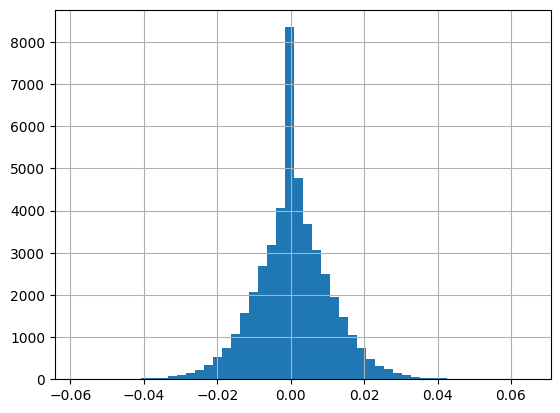

In [16]:
nav_df["daily_return"].dropna().hist(bins=50)
plt.show()

In [19]:
def calculate_cagr(fund_df, years):

    end_date = fund_df["date"].max()

    start_date = end_date - pd.DateOffset(years=years)

    temp = fund_df[
        fund_df["date"] >= start_date
    ]

    if len(temp) < 2:
        return None

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
    ) - 1

    return cagr

In [20]:
cagr_results = []

for code, fund in nav_df.groupby("amfi_code"):

    cagr_1y = calculate_cagr(fund, 1)
    cagr_3y = calculate_cagr(fund, 3)
    cagr_5y = calculate_cagr(fund, 5)

    cagr_results.append(
        [code, cagr_1y, cagr_3y, cagr_5y]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr_1y",
        "cagr_3y",
        "cagr_5y"
    ]
)

cagr_df.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [1]:
RISK_FREE = 0.065

def calculate_sharpe(returns):

    returns = returns.dropna()

    if len(returns) < 2:
        return None

    annual_return = returns.mean() * 252

    annual_volatility = (
        returns.std() * np.sqrt(252)
    )

    if annual_volatility == 0:
        return None

    return (
        annual_return - RISK_FREE
    ) / annual_volatility

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [7]:
nav_df = pd.read_csv(
    "../data/processed/02_nav_history_cleaned.csv"
)

nav_df["date"] = pd.to_datetime(
    nav_df["date"]
)

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)

nav_df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [8]:
nav_df.shape

(46000, 4)

In [9]:
RISK_FREE = 0.065

def calculate_sharpe(returns):

    returns = returns.dropna()

    if len(returns) < 2:
        return None

    annual_return = returns.mean() * 252

    annual_volatility = (
        returns.std() * np.sqrt(252)
    )

    if annual_volatility == 0:
        return None

    return (
        annual_return - RISK_FREE
    ) / annual_volatility

In [10]:
sharpe_results = []

for code, fund in nav_df.groupby("amfi_code"):

    sharpe = calculate_sharpe(
        fund["daily_return"]
    )

    sharpe_results.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [11]:
def calculate_sortino(returns):

    returns = returns.dropna()

    if len(returns) < 2:
        return None

    annual_return = (
        returns.mean() * 252
    )

    downside_returns = returns[
        returns < 0
    ]

    if len(downside_returns) < 2:
        return None

    downside_std = (
        downside_returns.std()
        * np.sqrt(252)
    )

    if downside_std == 0:
        return None

    sortino = (
        annual_return - RISK_FREE
    ) / downside_std

    return sortino

In [12]:
sortino_results = []

for code, fund in nav_df.groupby("amfi_code"):

    sortino = calculate_sortino(
        fund["daily_return"]
    )

    sortino_results.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [13]:
sortino_df.head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [14]:
benchmark_df = pd.read_csv(
    "../data/processed/10_benchmark_indices_cleaned.csv"
)

print(benchmark_df.columns.tolist())
print(benchmark_df.shape)

benchmark_df.head()

['date', 'index_name', 'close_value']
(8050, 3)


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [15]:
benchmark_df = pd.read_csv(
    "../data/processed/10_benchmark_indices_cleaned.csv"
)

benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"]
)

nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [16]:
nifty100[
    ["date",
     "close_value",
     "benchmark_return"]
].head()

,date,close_value,benchmark_return
1150,2022-01-03,17778.24,NaN
1151,2022-01-04,17537.52,-0.013540
1152,2022-01-05,17607.73,0.004003
1153,2022-01-06,17556.05,-0.002935
1154,2022-01-07,17664.02,0.006150


In [17]:
alpha_beta_results = []

In [18]:
for code, fund in nav_df.groupby("amfi_code"):

    temp = fund.merge(
        nifty100[
            ["date",
             "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    temp = temp.dropna()

    if len(temp) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )

    beta = slope

    alpha = intercept * 252

    alpha_beta_results.append(
        [code, alpha, beta]
    )

In [19]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [20]:
alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).head(10)

,amfi_code,alpha,beta
21,119598,0.303370,-0.023196
39,149324,0.300579,0.011455
25,120505,0.292636,0.000549
36,148569,0.282704,0.018134
30,120843,0.273305,-0.022830
2,100033,0.271954,0.005104
34,148567,0.269838,0.023684
38,149323,0.265986,-0.002523
16,119094,0.260767,-0.066265
19,119551,0.232010,-0.031751


In [21]:
alpha_beta_df.sort_values(
    "beta",
    ascending=False
).head(10)

,amfi_code,alpha,beta
11,118634,0.175007,0.103497
22,119599,0.048824,0.062002
32,125497,0.177298,0.048820
26,120506,0.162539,0.041896
28,120841,0.130429,0.036356
15,119093,0.082328,0.025883
34,148567,0.269838,0.023684
3,101206,0.213998,0.021086
36,148569,0.282704,0.018134
29,120842,0.078044,0.018057


In [22]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [23]:
def calculate_max_drawdown(nav_series):

    running_max = nav_series.cummax()

    drawdown = (
        nav_series / running_max
    ) - 1

    return drawdown.min()

In [24]:
drawdown_results = []

for code, fund in nav_df.groupby("amfi_code"):

    mdd = calculate_max_drawdown(
        fund["nav"]
    )

    drawdown_results.append(
        [code, mdd]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [25]:
drawdown_df.sort_values(
    "max_drawdown"
).head(10)

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


In [26]:
tracking_error_results = []

In [27]:
for code, fund in nav_df.groupby("amfi_code"):

    temp = fund.merge(
        nifty100[
            ["date",
             "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    temp = temp.dropna()

    if len(temp) < 30:
        continue

    tracking_error = (
        (
            temp["daily_return"]
            -
            temp["benchmark_return"]
        ).std()
        * np.sqrt(252)
    )

    tracking_error_results.append(
        [code, tracking_error]
    )

In [28]:
tracking_error_df = pd.DataFrame(
    tracking_error_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df.head()

,amfi_code,tracking_error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


In [29]:
drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [30]:
tracking_error_df.head()

,amfi_code,tracking_error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


In [31]:
drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [32]:
fund_master = pd.read_csv(
    "../data/processed/01_fund_master_cleaned.csv"
)

print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [34]:
print("nav_df exists:", "nav_df" in globals())
print("cagr_df exists:", "cagr_df" in globals())
print("sharpe_df exists:", "sharpe_df" in globals())
print("alpha_beta_df exists:", "alpha_beta_df" in globals())
print("drawdown_df exists:", "drawdown_df" in globals())
print("fund_master exists:", "fund_master" in globals())

nav_df exists: True
cagr_df exists: False
sharpe_df exists: True
alpha_beta_df exists: True
drawdown_df exists: True
fund_master exists: True


In [35]:
def calculate_cagr(fund_df, years):

    end_date = fund_df["date"].max()

    start_date = end_date - pd.DateOffset(years=years)

    temp = fund_df[
        fund_df["date"] >= start_date
    ]

    if len(temp) < 2:
        return None

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    return (
        (end_nav / start_nav)
        ** (1 / years)
    ) - 1

In [36]:
cagr_results = []

for code, fund in nav_df.groupby("amfi_code"):

    cagr_results.append([
        code,
        calculate_cagr(fund, 1),
        calculate_cagr(fund, 3),
        calculate_cagr(fund, 5)
    ])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr_1y",
        "cagr_3y",
        "cagr_5y"
    ]
)

cagr_df.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [37]:
print(cagr_df.shape)

(40, 4)


In [38]:
cagr_df["cagr_rank"] = (
    cagr_df["cagr_3y"]
    .rank(ascending=False)
)

sharpe_df["sharpe_rank"] = (
    sharpe_df["sharpe_ratio"]
    .rank(ascending=False)
)

alpha_beta_df["alpha_rank"] = (
    alpha_beta_df["alpha"]
    .rank(ascending=False)
)

drawdown_df["drawdown_rank"] = (
    drawdown_df["max_drawdown"]
    .rank(ascending=False)
)

fund_master["expense_rank"] = (
    fund_master["expense_ratio_pct"]
    .rank(ascending=True)
)

In [39]:
print(cagr_df.shape)

(40, 5)


In [40]:
cagr_df["cagr_rank"] = (
    cagr_df["cagr_3y"]
    .rank(ascending=False)
)

sharpe_df["sharpe_rank"] = (
    sharpe_df["sharpe_ratio"]
    .rank(ascending=False)
)

alpha_beta_df["alpha_rank"] = (
    alpha_beta_df["alpha"]
    .rank(ascending=False)
)

drawdown_df["drawdown_rank"] = (
    drawdown_df["max_drawdown"]
    .rank(ascending=False)
)

fund_master["expense_rank"] = (
    fund_master["expense_ratio_pct"]
    .rank(ascending=True)
)

print("Ranking columns created successfully")

Ranking columns created successfully


In [41]:
scorecard_df = (
    cagr_df[
        ["amfi_code", "cagr_3y", "cagr_rank"]
    ]
    .merge(
        sharpe_df[
            ["amfi_code", "sharpe_ratio", "sharpe_rank"]
        ],
        on="amfi_code"
    )
    .merge(
        alpha_beta_df[
            ["amfi_code", "alpha", "beta", "alpha_rank"]
        ],
        on="amfi_code"
    )
    .merge(
        drawdown_df[
            ["amfi_code", "max_drawdown", "drawdown_rank"]
        ],
        on="amfi_code"
    )
    .merge(
        fund_master[
            ["amfi_code", "expense_ratio_pct", "expense_rank"]
        ],
        on="amfi_code"
    )
)

scorecard_df.head()

,amfi_code,cagr_3y,cagr_rank,sharpe_ratio,sharpe_rank,alpha,beta,alpha_rank,max_drawdown,drawdown_rank,expense_ratio_pct,expense_rank
0,100016,0.012926,35.0,-0.201517,35.0,0.037476,-0.058268,39.0,-0.247344,34.0,1.55,32.0
1,100025,0.039164,34.0,-0.567095,39.0,0.042818,0.001158,38.0,-0.043083,4.0,0.56,2.0
2,100033,0.324425,4.0,1.093699,7.0,0.271954,0.005104,6.0,-0.162172,20.0,1.38,17.0
3,101206,0.289677,9.0,1.027213,9.0,0.213998,0.021086,12.0,-0.112916,9.0,1.60,36.5
4,101207,-0.041524,39.0,0.162661,28.0,0.108971,-0.065289,27.0,-0.354469,38.0,1.53,28.5


In [42]:
scorecard_df.shape

(40, 12)

In [44]:
max_rank = 40

scorecard_df["cagr_score"] = (
    max_rank - scorecard_df["cagr_rank"] + 1
) / max_rank

scorecard_df["sharpe_score"] = (
    max_rank - scorecard_df["sharpe_rank"] + 1
) / max_rank

scorecard_df["alpha_score"] = (
    max_rank - scorecard_df["alpha_rank"] + 1
) / max_rank

scorecard_df["expense_score"] = (
    max_rank - scorecard_df["expense_rank"] + 1
) / max_rank

scorecard_df["drawdown_score"] = (
    max_rank - scorecard_df["drawdown_rank"] + 1
) / max_rank

In [45]:
scorecard_df["fund_score"] = (
      0.30 * scorecard_df["cagr_score"]
    + 0.25 * scorecard_df["sharpe_score"]
    + 0.20 * scorecard_df["alpha_score"]
    + 0.15 * scorecard_df["expense_score"]
    + 0.10 * scorecard_df["drawdown_score"]
) * 100

In [46]:
scorecard_df["overall_rank"] = (
    scorecard_df["fund_score"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [47]:
scorecard_df.sort_values(
    "fund_score",
    ascending=False
)[
    ["amfi_code",
     "fund_score",
     "overall_rank"]
].head(10)

,amfi_code,fund_score,overall_rank
34,148567,86.2500,1.0
25,120505,82.2500,2.0
30,120843,82.0000,3.0
2,100033,80.7500,4.0
24,120504,80.0000,5.0
16,119094,77.0000,6.0
19,119551,74.8125,7.0
36,148569,73.6875,8.0
3,101206,68.1875,9.0
21,119598,67.3750,10.0


In [48]:
scorecard_df.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [49]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [50]:
performance_metrics = (
    cagr_df
    .merge(
        sharpe_df[["amfi_code","sharpe_ratio"]],
        on="amfi_code"
    )
    .merge(
        sortino_df[["amfi_code","sortino_ratio"]],
        on="amfi_code"
    )
    .merge(
        alpha_beta_df,
        on="amfi_code"
    )
    .merge(
        drawdown_df,
        on="amfi_code"
    )
    .merge(
        tracking_error_df,
        on="amfi_code"
    )
)

performance_metrics.to_csv(
    "../data/processed/performance_metrics.csv",
    index=False
)

performance_metrics.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y,cagr_rank,sharpe_ratio,sortino_ratio,alpha,beta,alpha_rank,max_drawdown,drawdown_rank,tracking_error
0,100016,-0.022243,0.012926,0.023168,35.0,-0.201517,-0.351047,0.037476,-0.058268,39.0,-0.247344,34.0,0.199284
1,100025,0.037050,0.039164,0.039127,34.0,-0.567095,-0.941821,0.042818,0.001158,38.0,-0.043083,4.0,0.134535
2,100033,0.532324,0.324425,0.260741,4.0,1.093699,1.829134,0.271954,0.005104,6.0,-0.162172,20.0,0.228699
3,101206,0.479241,0.289677,0.204427,9.0,1.027213,1.799563,0.213998,0.021086,12.0,-0.112916,9.0,0.192706
4,101207,-0.239860,-0.041524,0.069533,39.0,0.162661,0.276644,0.108971,-0.065289,27.0,-0.354469,38.0,0.292117


In [51]:
scorecard_df.sort_values(
    "fund_score",
    ascending=False
)[["amfi_code","fund_score","overall_rank"]].head(10)

,amfi_code,fund_score,overall_rank
34,148567,86.2500,1.0
25,120505,82.2500,2.0
30,120843,82.0000,3.0
2,100033,80.7500,4.0
24,120504,80.0000,5.0
16,119094,77.0000,6.0
19,119551,74.8125,7.0
36,148569,73.6875,8.0
3,101206,68.1875,9.0
21,119598,67.3750,10.0


In [52]:
benchmark_df["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [53]:
top5_codes = (
    scorecard_df
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)["amfi_code"]
    .tolist()
)

top5_codes

[148567, 120505, 120843, 100033, 120504]

In [54]:
top5_nav = nav_df[
    nav_df["amfi_code"].isin(top5_codes)
].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return
2300,100033,2022-01-03,107.3758,NaN
2301,100033,2022-01-04,105.9447,-0.013328
2302,100033,2022-01-05,105.4800,-0.004386
2303,100033,2022-01-06,104.9350,-0.005167
2304,100033,2022-01-07,104.3318,-0.005748


In [55]:
top5_nav["normalized_nav"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(
        lambda x: x / x.iloc[0] * 100
    )
)

In [56]:
nifty50 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

In [57]:
nifty50["normalized"] = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
    * 100
)

nifty100["normalized"] = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
    * 100
)

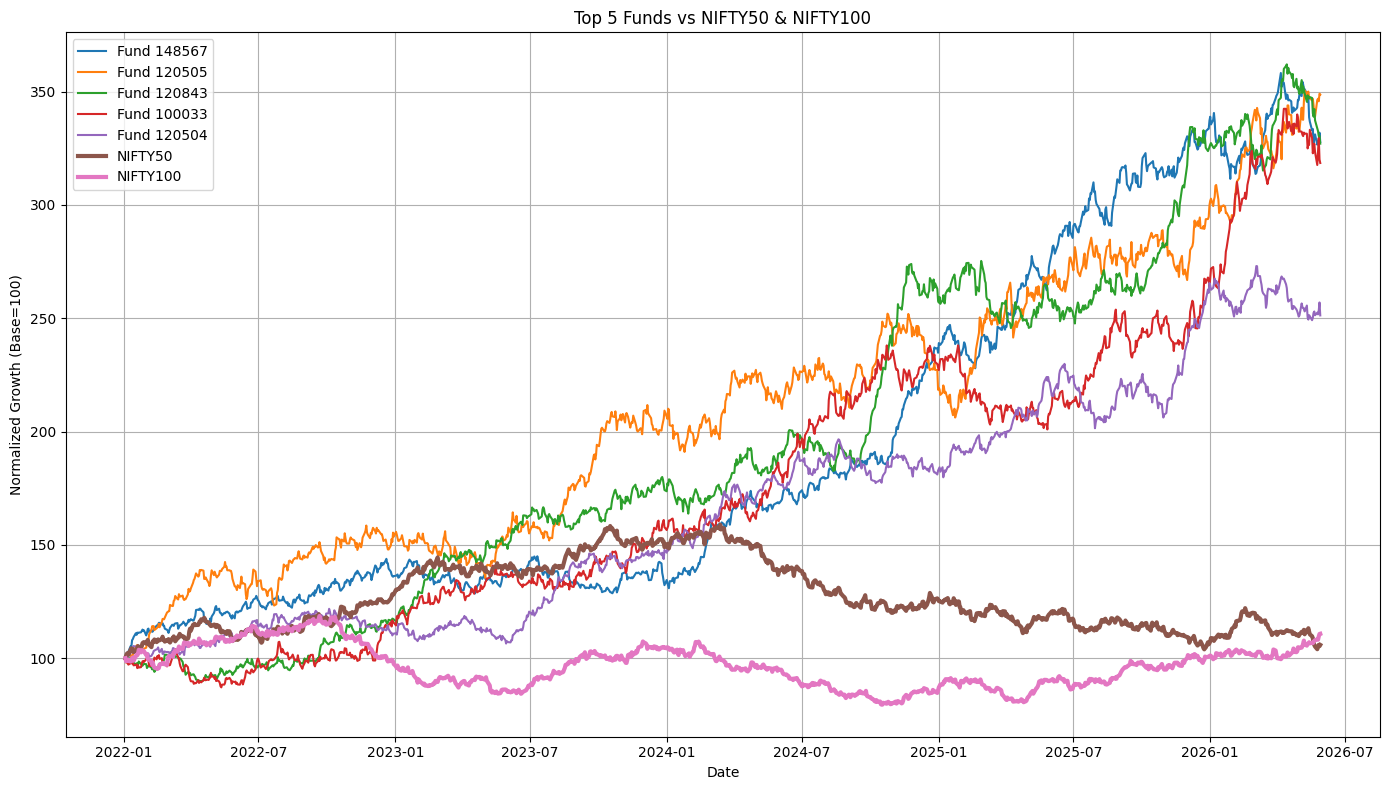

In [58]:
plt.figure(figsize=(14,8))

for code in top5_codes:

    temp = top5_nav[
        top5_nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["normalized_nav"],
        label=f"Fund {code}"
    )

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    label="NIFTY50",
    linewidth=3
)

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    label="NIFTY100",
    linewidth=3
)

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100"
)

plt.xlabel("Date")
plt.ylabel("Normalized Growth (Base=100)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../data/processed/benchmark_comparison.png"
)

plt.show()

In [59]:
import os

os.path.exists(
    "../data/processed/benchmark_comparison.png"
)

True